In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier as RFC

In [2]:
import tensorflow as tf
tf.get_logger().setLevel(40) # suppress deprecation messages
from tensorflow.keras.layers import Dense, Input, Embedding, Concatenate, Reshape, Dropout, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

In [4]:
data  = pd.read_csv('diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
data.shape

(768, 9)

In [6]:
data.duplicated().any()

np.False_

In [7]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64


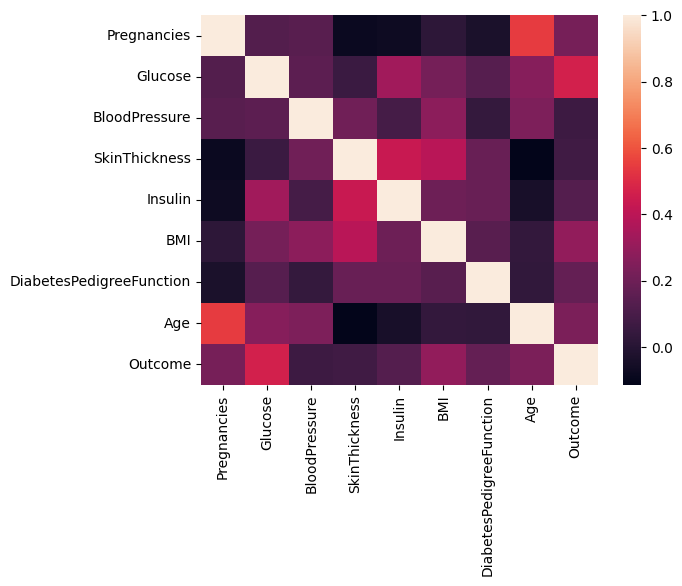

In [8]:
print(data.corr()['Outcome'])
sns.heatmap(data.corr())
plt.show()

In [9]:
data[(data['BMI'] == 0) & (data['Glucose'] == 0) & (data['BloodPressure'] == 0)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [10]:
data[(data['Glucose'] == 0)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [11]:
cleaned_data = data[(data['Glucose'] != 0)]
cleaned_data.shape

(763, 9)

In [12]:
x=cleaned_data.iloc[:,:-1]
y=cleaned_data.iloc[:,-1:]

In [13]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
rfc=RFC( n_estimators=100,n_jobs=-1)

In [15]:
k=rfc.fit(xtrain,ytrain)

C:\Users\ADMIN\tf_env\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [20]:
m=k.feature_importances_

In [22]:
m=pd.DataFrame(m)

In [23]:
m.head()

,0
0,0.085864
1,0.255260
2,0.088757
3,0.069095
4,0.072518


In [30]:
m['names']=data.columns[:-1]


In [31]:
m.head()

,0,names
0,0.085864,Pregnancies
1,0.255260,Glucose
2,0.088757,BloodPressure
3,0.069095,SkinThickness
4,0.072518,Insulin


In [33]:
m.sort_values(by=[0],inplace=True)

In [34]:
m.head()

,0,names
3,0.069095,SkinThickness
4,0.072518,Insulin
0,0.085864,Pregnancies
2,0.088757,BloodPressure
6,0.124383,DiabetesPedigreeFunction


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'SkinThickness'),
  Text(1, 0, 'Insulin'),
  Text(2, 0, 'Pregnancies'),
  Text(3, 0, 'BloodPressure'),
  Text(4, 0, 'DiabetesPedigreeFunction'),
  Text(5, 0, 'Age'),
  Text(6, 0, 'BMI'),
  Text(7, 0, 'Glucose')])

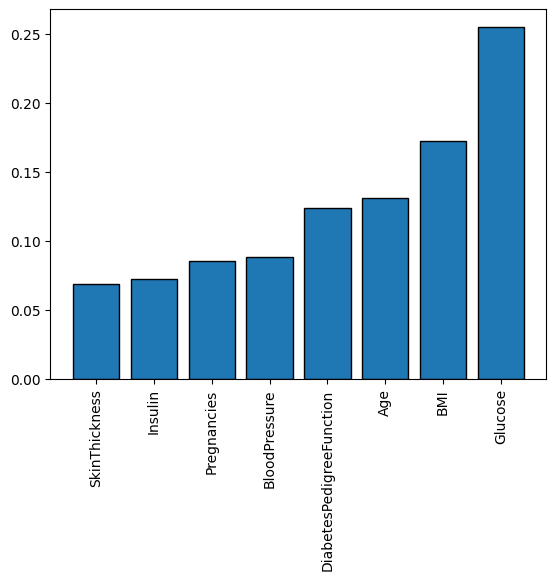

In [41]:
plt.bar(m['names'],m[0],edgecolor='black')
plt.xticks(rotation=90)

In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from matplotlib import pyplot

In [44]:
model = KNeighborsClassifier()
# fit the model
model.fit(xtrain, ytrain)

C:\Users\ADMIN\tf_env\lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [46]:
r=permutation_importance(model,xtrain,ytrain,scoring="accuracy")

In [50]:
imp=r.importances_mean

In [51]:
imp

array([0.00557377, 0.15311475, 0.03114754, 0.03213115, 0.0852459 ,
       0.02688525, 0.        , 0.05737705])

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Pregnancies'),
  Text(1, 0, 'Glucose'),
  Text(2, 0, 'BloodPressure'),
  Text(3, 0, 'SkinThickness'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'BMI'),
  Text(6, 0, 'DiabetesPedigreeFunction'),
  Text(7, 0, 'Age')])

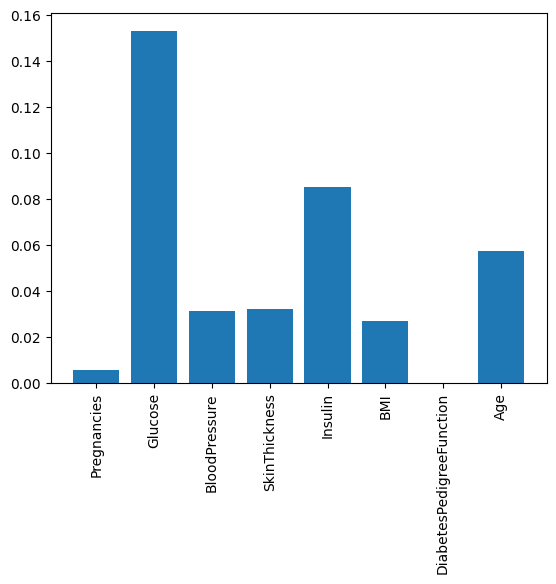

In [54]:
plt.bar(data.columns[:-1],imp)
plt.xticks(rotation=90)

In [56]:
#sensitivity analysis
m.head()

,0,names
3,0.069095,SkinThickness
4,0.072518,Insulin
0,0.085864,Pregnancies
2,0.088757,BloodPressure
6,0.124383,DiabetesPedigreeFunction


In [76]:
def sen(r,feature_index,xtest):
    l=[]
    max1=xtest.values[:,feature_index].max()
    min1=xtest.values[:,feature_index].min()
    k=np.linspace(min1,max1,100)
    for i in k:
        x_mod=xtest.copy()
        x_mod.values[:,feature_index]=i
        m=model.predict_proba(xtest)[:,1]
        l.append(m.mean())
    return k,l
        

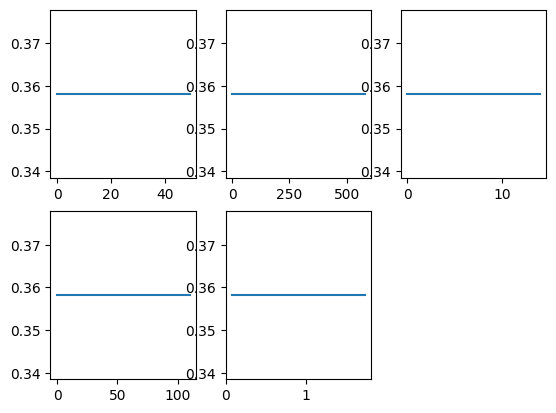

In [77]:
top_features=m.head(5)
for ind,(_,row) in enumerate(top_features.iterrows(),1):
    feature_index=list(data.columns).index(row["names"])
    r1,x=sen(model,feature_index,xtest)
    plt.subplot(2,3,ind)
    plt.plot(r1,x)
    
    
    